# Rossman Store Sales Prediction
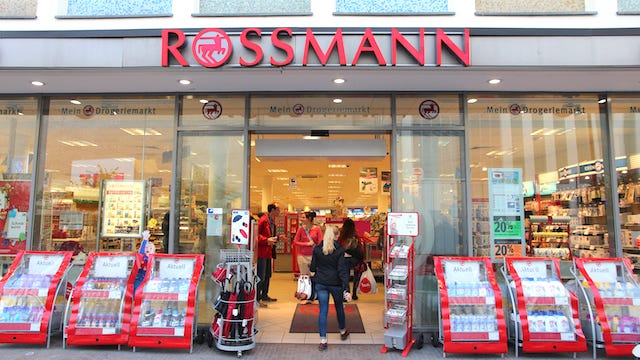

by Chin Yung Xuan

In [1]:
import pandas as pd

## 1) Importing Datasets

In [2]:
df_sales_train = pd.read_csv('train.csv')
df_sales_train.head(10)

C:\Users\User\AppData\Local\Temp\ipykernel_4584\2590518724.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sales_train = pd.read_csv('train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [3]:
df_sales_test = pd.read_csv('test.csv')
df_sales_test.head(10)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
5,6,10,4,2015-09-17,1.0,1,0,0
6,7,11,4,2015-09-17,1.0,1,0,0
7,8,12,4,2015-09-17,1.0,1,0,0
8,9,13,4,2015-09-17,1.0,1,0,0
9,10,14,4,2015-09-17,1.0,1,0,0


In [4]:
df_additional = pd.read_csv('store.csv')
df_additional.head(10) 

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


## 2) Data Exploration

Column explanation:
(i) train and test datasets (sales historical data)
- 

In [5]:
df_sales_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [6]:
df_sales_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  object 
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  object 
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 2.5+ MB


Most columns are self-explanatory. 'Id' in test data is the PK that represents a (Store, Date) duple within the test set. One of the differences between the train and test dataset is that the train dataset has the 'Sales' column, which allows the model the recognize it and learn based on it. The accuracy of the model will then be tested using the test dataset without the 'Sales' column, to see how well each model perform.

The next difference between the 2 is that the train data has 'Customers' column while the test data doesn't. This is because if we want to predict the Sales for future dates of stores, we wouldn't know the customer flow until the day is actually over. Also, the model will over-rely on the 'Customers' variable to predict sales if we use it to train the model. Therefore, it will be best for us to only use the 'Customers' column in the train data for EDA, and not use it for building the prediction model.

## Column explanation: (ii) df_additional

In [7]:
df_additional.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


This df_additional dataset shows the details for each store.

- StoreType - differentiates between 4 different store models: a, b, c, d
- Assortment - describes an assortment level: a = basic, b = extra, c = extended
- CompetitionDistance - distance in meters to the nearest competitor store
- CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
- Promo - indicates whether a store is running a promo on that day
- Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating
- Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2
- PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

In [8]:
df_sales_train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [9]:
df_sales_test.describe()

,Id,Store,DayOfWeek,Open,Promo,SchoolHoliday
count,41088.000000,41088.000000,41088.000000,41077.000000,41088.000000,41088.000000
mean,20544.500000,555.899533,3.979167,0.854322,0.395833,0.443487
std,11861.228267,320.274496,2.015481,0.352787,0.489035,0.496802
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,10272.750000,279.750000,2.000000,1.000000,0.000000,0.000000
50%,20544.500000,553.500000,4.000000,1.000000,0.000000,0.000000
75%,30816.250000,832.250000,6.000000,1.000000,1.000000,1.000000
max,41088.000000,1115.000000,7.000000,1.000000,1.000000,1.000000


In [10]:
df_additional.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [11]:
df_sales_train.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [12]:
df_sales_test.isna().sum()

Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64

In [13]:
df_additional.isna().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

## 3) Light Data Cleaning 

(before EDA) - light cleaning
- Change data type (dates, 0/1 to boolean, or any others)
- Clean missing values

In [14]:
# Change date data type from predefined 'object' to 'datetime'
df_sales_train['Date'] = pd.to_datetime(df_sales_train['Date'])
df_sales_test['Date'] = pd.to_datetime(df_sales_test['Date'])

In [15]:
# Did not convert 'Open', 'Promo', and 'SchoolHoliday' columns into boolean data type because the initial 0 and 1 
# value column can be understand by the machine when building the machine learning models

In [16]:
# Clean Missing Values

# The 11 missing values in the 'Open' column of the test set can be ignored; this allows us to evaluate whether the
# model remains robust even when the store's operational status is unknown for those specific rows.

In [17]:
# Clean df_additional missing values
df_additional['CompetitionDistance'].fillna(df_additional['CompetitionDistance'].median(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4584\1382269472.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_additional['CompetitionDistance'].fillna(df_additional['CompetitionDistance'].median(), inplace=True)


In [18]:
df_additional['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
df_additional['CompetitionOpenSinceYear'].fillna(0, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4584\1186850682.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_additional['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_4584\1186850682.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

In [19]:
df_additional.fillna({'Promo2SinceYear': 0}, inplace=True)
df_additional.fillna({'Promo2SinceWeek': 0}, inplace=True)
df_additional.fillna({'PromoInterval': 'None'}, inplace=True)

In [20]:
df_additional.isna().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

## 4) EDA

(a) For train and test dataset

In [21]:
import matplotlib.pyplot as plt

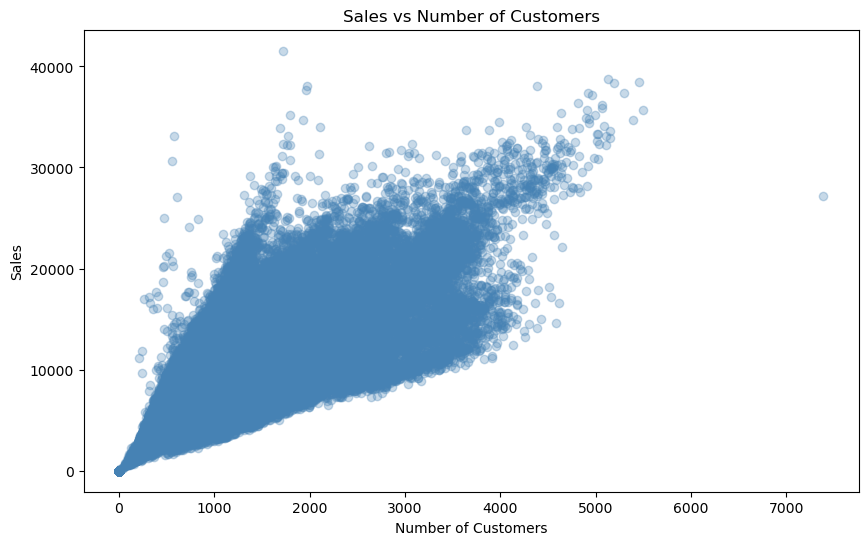

In [22]:
# Scatter plot for Sales vs. Customers
# df_sales_train
plt.figure(figsize=(10, 6))
plt.scatter(df_sales_train['Customers'], df_sales_train['Sales'], alpha=0.3, color='steelblue')

plt.title('Sales vs Number of Customers')
plt.xlabel('Number of Customers')
plt.ylabel('Sales')
plt.show()

Interpretation for scatter plot:
As the number of customers increase, sales increase. This shows that customers walking into the store can directly affect the sales. 
Also, the fan-shaped pattern of the scatter plot also shows the spread of sales values widen as customer count increases. This shows that stores with fewer customers tend to have more consistent and predictable sales. This indicates that although Customers is a huge contributor in predicting the Sales, other factors like are likely to affect Sales slightly as well.

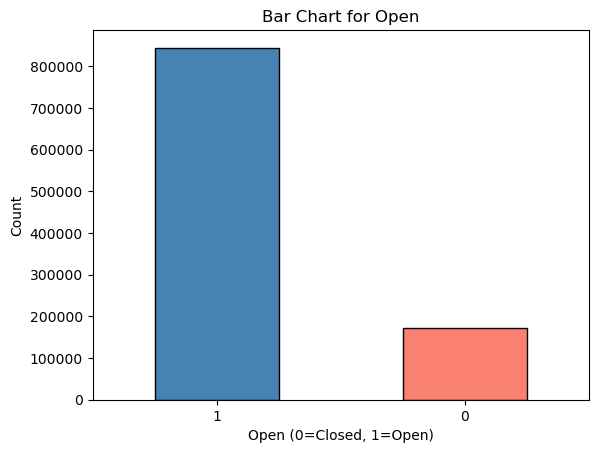

In [23]:
# Bar chart for 'Open' column
df_sales_train['Open'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')

plt.title('Bar Chart for Open')
plt.xlabel('Open (0=Closed, 1=Open)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In this train dataset, there are over 800k sales data that has the store open, while only below 200k sales data has their store closed. This indicates an imbalance in data, which alerts us to be cautious when using this column as a predictor. 

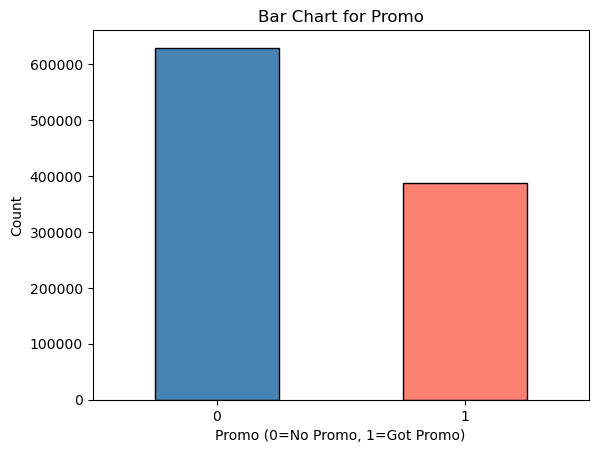

In [24]:
# Bar chart for 'Promo' column
df_sales_train['Promo'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')

plt.title('Bar Chart for Promo')
plt.xlabel('Promo (0=No Promo, 1=Got Promo)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In the training dataset, there are more sales records without promotions than sales records with promotions.This couls make the model learn normal sales transaction better compared to sales data that have promotion. For example, if promo increases sales, the model might underestimate it due to fewer promo samples.

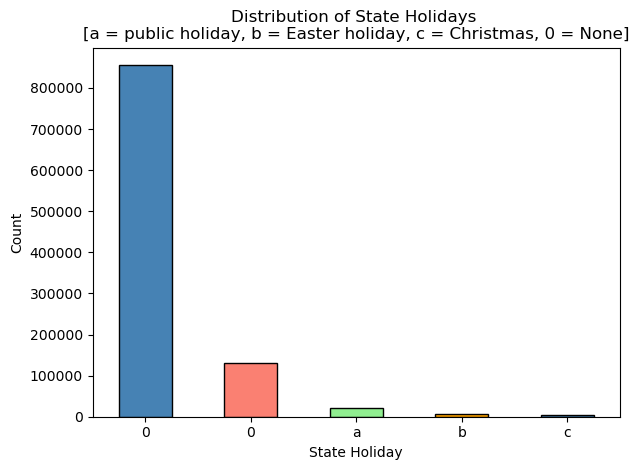

In [25]:
# Bar Chart for 'StateHoliday'

colors = ['steelblue', 'salmon', 'lightgreen', 'orange']
df_sales_train['StateHoliday'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title('Distribution of State Holidays \n[a = public holiday, b = Easter holiday, c = Christmas, 0 = None]')
plt.xlabel('State Holiday')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Most Sales data has no state holidays ongoing at that moment 

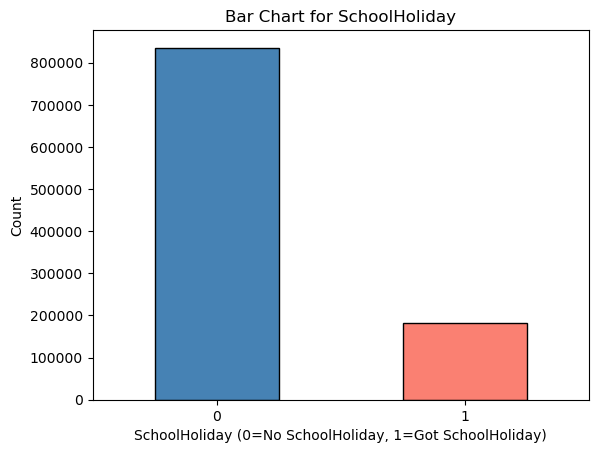

In [26]:
# Bar chart for 'SchoolHoliday' 

df_sales_train['SchoolHoliday'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')

plt.title('Bar Chart for SchoolHoliday')
plt.xlabel('SchoolHoliday (0=No SchoolHoliday, 1=Got SchoolHoliday)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Most sales records happened during non-school holidays. The model might be more familiar with data with no school holidays, and might ignore the rise in sales during school holidays.

(b) For df_additional dataset

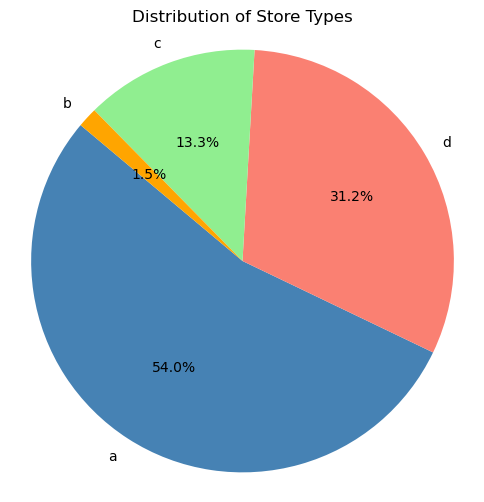

In [27]:
# Distribution of 'StoreType' in df_additional using Pie Chart
store_type_counts = df_additional['StoreType'].value_counts()
colors = ['steelblue', 'salmon', 'lightgreen', 'orange']
plt.figure(figsize=(6, 6))
plt.pie(store_type_counts, labels=store_type_counts.index, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Store Types')
plt.axis('equal')
plt.show()

Store type 'a' takes up most of the distribution, followed by 'd', 'c', and 'b'.

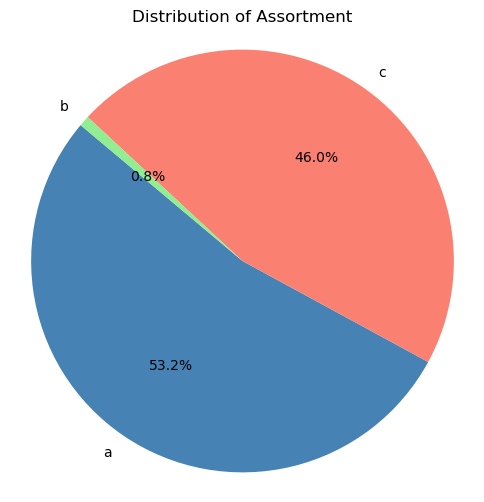

In [28]:
# Distribution of 'Assortment' in df_additional using Pie Chart
store_type_counts = df_additional['Assortment'].value_counts()
colors = ['steelblue', 'salmon', 'lightgreen']
plt.figure(figsize=(6, 6))
plt.pie(store_type_counts, labels=store_type_counts.index, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Assortment')
plt.axis('equal')
plt.show()

a (basic) takes up the largest percent of the entire additional dataset, followed by c (extended) and b (extra). This shows that most of the sales records come from basic store. This could be because there are more basic stores, are the items are priced more premiumly in extended and extra stores, leading to lower transactions.

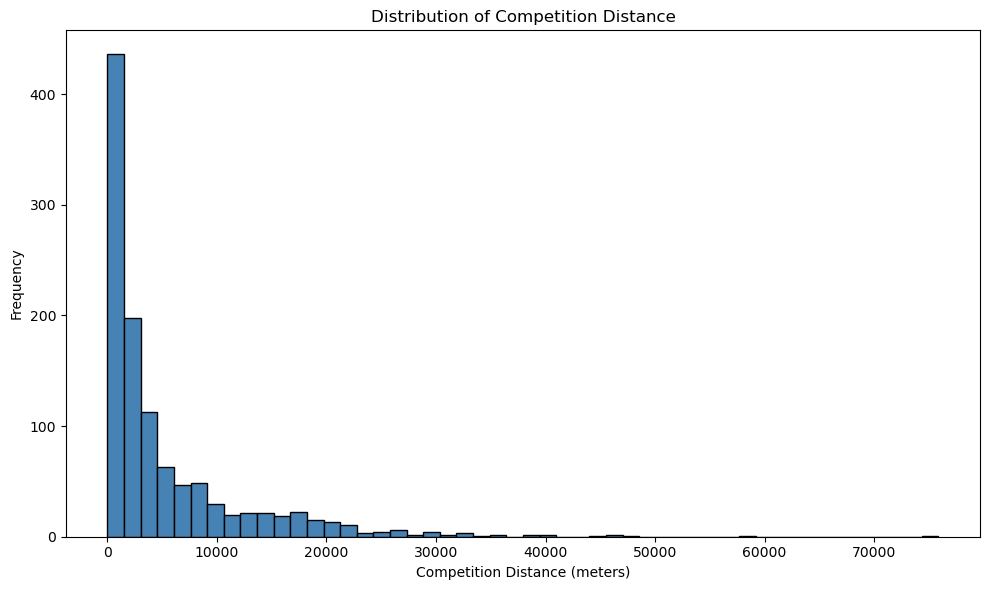

In [29]:
# Graph for 'CompetitionDistance' in df_additional using Histogram

plt.figure(figsize=(10, 6))
plt.hist(df_additional['CompetitionDistance'], bins=50, color='steelblue', edgecolor='black')

plt.title('Distribution of Competition Distance')
plt.xlabel('Competition Distance (meters)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

This histogram shows a right-skewed distribution, which means that majority of the stores are located close to their nearest competitor. This heavily skewed distribution suggest that a log transformation should be applied to normalize this column before feeding it into our model. 

(REMINDER) NEXT STEPS: merge the sales dataset (train) with df_addition

## 5) Heavy Data Cleaning

(after EDA) - heavy cleaning to prepare for modelling process
- One-hot encoding to convert categorical values to numerical for machine to understand (StoreType, Assortment) (create additional columns)
- Min-Max normalization to convert columns with values that are on too large scales, scaling them to between 0 and 1.
- Remove unneceesary columns, such as identifiers.
- Apply log transformation for highly skewed columns

In [30]:
df_sales_train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [31]:
df_sales_test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [32]:
df_additional.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,None
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,None


In [33]:
# 1) Clean df_additional dataset 
# (a) Clean 'CompetitionDistance' column: using log transformation to reduce the skewness of the 'CompetitionDistance' column

import numpy as np
df_additional['CompetitionDistance'] = np.log1p(df_additional['CompetitionDistance'])

In [34]:
# (b) Clean 'CompetitionOpenSinceMonth' column: apply min=max normalization to scale the months value between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_additional['CompetitionOpenSinceMonth'] = scaler.fit_transform(df_additional[['CompetitionOpenSinceMonth']])

In [35]:
# (c) Clean 'CompetitionOpenSinceYear' column: same as 'CompetitionOpenSinceMonth' column, apply min=max normalization to scale the years value between 0 and 1
df_additional['CompetitionOpenSinceYear'] = scaler.fit_transform(df_additional[['CompetitionOpenSinceYear']])

In [36]:
# (d) Clean 'Promo2SinceWeek' column: min-max normalization
df_additional['Promo2SinceWeek'] = scaler.fit_transform(df_additional[['Promo2SinceWeek']])

In [37]:
# (e) Clean 'Promo2SinceYear' column: min-max normalization
df_additional['Promo2SinceYear'] = scaler.fit_transform(df_additional[['Promo2SinceYear']])

In [38]:
# (f) Clean 'PromoInterval' column: apply one-hot encoding to convert the categorical values into binary columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_additional['PromoInterval'] = le.fit_transform(df_additional['PromoInterval'])

In [39]:
# View all values in 'PromoInterval' column after label encoding
print(df_additional['PromoInterval'].unique())

[3 1 0 2]


In [40]:
# (g) Clean 'StoreType' 'Assortment' columns: apply one-hot encoding to convert the categorical values into binary columns
df_additional['StoreType'] = le.fit_transform(df_additional['StoreType'])
df_additional['Assortment'] = le.fit_transform(df_additional['Assortment'])

In [41]:
df_additional.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,0,7.147559,0.750000,0.996526,0,0.00,0.000000,3
1,2,0,0,6.347389,0.916667,0.996030,1,0.26,0.997519,1
2,3,0,0,9.556126,1.000000,0.995533,1,0.28,0.998015,1
3,4,2,2,6.431331,0.750000,0.997022,0,0.00,0.000000,3
4,5,0,0,10.305982,0.333333,1.000000,0,0.00,0.000000,3


In [42]:
# 2) Clean df_sales_train and df_sales_test datasets
# (a) Clean 'DayOfWeek' column: min-max normalization to scale the days of the week value between 0 and 1
df_sales_train['DayOfWeek'] = scaler.fit_transform(df_sales_train[['DayOfWeek']])

In [43]:
# (b) Remove 'Customer' column from df_sales_train as it is not a feature that can be used for prediction and may lead to data leakage if included in the model training process. The 'Customer' column represents the number of customers visiting the store on a given day, which is directly related to the target variable 'Sales'. Including it in the model would allow the model to learn from this information, which would not be available in real-world scenarios when making predictions. Therefore, it is best to remove the 'Customer' column to ensure that the model is trained on features that are truly predictive of sales and can be used for making accurate predictions in practice.
df_sales_train.drop(columns=['Customers'], inplace=True)

In [44]:
df_sales_train.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday
0,1,0.666667,2015-07-31,5263,1,1,0,1
1,2,0.666667,2015-07-31,6064,1,1,0,1
2,3,0.666667,2015-07-31,8314,1,1,0,1
3,4,0.666667,2015-07-31,13995,1,1,0,1
4,5,0.666667,2015-07-31,4822,1,1,0,1


In [45]:
# (c) remove column 'Id' from df_sales_test dataset
df_sales_test.drop(columns=['Id'], inplace=True)

## 6) Merge Datasets 

In [46]:
df_train_merged = pd.merge(df_sales_train, df_additional, on='Store', how='left')
df_test_merged = pd.merge(df_sales_test, df_additional, on='Store', how='left')

Columns that need to be encoded:
- StateHoliday


In [47]:
# Replace the 'StateHoliday' column values in df_train_merged and df_test_merged with numerical values (0 for '0', 1 for 'a', 2 for 'b', and 3 for 'c')
df_train_merged['StateHoliday'] = df_train_merged['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3})
df_test_merged['StateHoliday'] = df_test_merged['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3})

In [48]:
# See how many null values in 'StateHoliday' column after label encoding
print(df_train_merged['StateHoliday'].isna().sum())
print(df_test_merged['StateHoliday'].isna().sum())

131072
0


In [49]:
# Replace all null values in 'StateHoliday' column with 0 (indicating no holiday) in df_train_merged 
df_train_merged['StateHoliday'].fillna(0, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_4584\2346787667.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_merged['StateHoliday'].fillna(0, inplace=True)


## 7) Modeling

Define Features and Target

In [50]:
X_train = df_train_merged.drop(columns=['Sales', 'Date', 'Store'])
y_train = df_train_merged['Sales']

X_test = df_test_merged.drop(columns=['Date', 'Store'])

Build the model

In [51]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [52]:
# Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Train on split
model.fit(X_train_split, y_train_split)

# Evaluate on validation set
y_pred_val = model.predict(X_val)

print('MAE:', mean_absolute_error(y_val, y_pred_val))
print('RMSE:', np.sqrt(mean_squared_error(y_val, y_pred_val)))
print('R² Score:', r2_score(y_val, y_pred_val))

MAE: 683.0554283942398
RMSE: 1138.824379924377
R² Score: 0.9123038174822362


In [53]:
# Final predictions on test set
y_pred_test = model.predict(X_test)

In [54]:
# Store predictions in a DataFrame
df_predictions = pd.DataFrame({
    'Predicted_Sales': y_pred_test
})

df_predictions.head(10)

,Predicted_Sales
0,5428.686080
1,8314.987186
2,9865.222108
3,5734.970910
4,7239.389240
5,5950.065977
6,8366.745175
7,8283.965782
8,6131.844071
9,6517.516849


In [ ]:
# Export model (if needed)

import pickle
with open('sales_model.pkl', 'wb') as f:
    pickle.dump(model, f)